# Spectrophotometric Distance Estimation — End-to-End Walkthrough

This notebook shows **every step** of the distance-estimation pipeline in this repo,
which reproduces and scores **Hogg, Eilers & Rix (2018)** ("spectrophotometric
parallaxes" for APOGEE red giants).

The pipeline, start to finish:

| step | what happens | where it lives |
|---|---|---|
| 1 | load the parent catalog (44,784 red giants) | `hogg2018.fits` |
| 2 | assemble features: 8-band photometry + APOGEE spectra | `assemble_features.py` (runs on Gadi) |
| 3 | fit the linear model $\ln\varpi^{(\mathrm{sp})} = \theta\cdot x$ in **parallax space** | demonstrated below on a toy problem |
| 4 | A/B cross-validation (never predict a star with a model that saw it) | `sample` column |
| 5 | predicted spectrophotometric parallaxes + uncertainties | `spec_parallax(_err)` columns |
| 6 | invert parallax → distance | this notebook |
| 7 | evaluate: robust scatter, bias, $\chi^2$ on the high-S/N probe | `spphot_eval.py` |
| 8 | diagnostic figures (Paper I Fig. 2, residual histogram) | `spphot_plots.py` |
| 9 | score your own model on identical footing | template at the end |

The published Zenodo catalog already contains the model's outputs, so steps 1, 4–8
run on the real data here. Step 2 needs the spectra (built on Gadi), and step 3 is
demonstrated with a fully working toy version of the exact same math.

## Step 1 — The data, and why we need this at all

The parent sample is APOGEE red-giant stars crossmatched to Gaia DR2. These are
**luminous, distant** stars — exactly the ones where Gaia's geometric parallax is
weakest. The whole point of the method: a star's spectrum + photometry predict its
luminosity (and hence parallax) far more precisely than Gaia can measure it
geometrically at these distances.

Two facts below motivate everything that follows:
- a noticeable fraction of Gaia parallaxes are **negative** (pure noise scatter), and
- most stars have **low Gaia parallax S/N**.

If you cut those stars away you bias the sample toward nearby stars; the method
instead *keeps them all* by fitting in parallax space (step 3).

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from astropy.io import fits
import sys
import polars as pl

from pathlib import Path
SRC = Path('/home/100/mj8805/scr_mk27/')
sys.path.append(str(SRC / 'distance-estimator'))

import spphot_eval as E
import spphot_plots as P   # note: this import switches matplotlib to Agg...
%matplotlib inline
# ...so the magic above switches it back for inline figures

PARQUET = SRC / 'bulge-ages-and-orbits' / 'data' / 'spectra_infer_parallax.parquet'
cat = pl.scan_parquet(PARQUET)


In [2]:
cat.columns

/jobfs/170570176.gadi-pbs/ipykernel_1974946/4017023853.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  cat.columns


['spectrum_pk',
 'release',
 'sdss_id',
 'telescope',
 'snr',
 'spectrum_flags',
 'continuum',
 'v_rad',
 'e_v_rad',
 'std_v_rad',
 'median_e_v_rad',
 'xcorr_v_rad',
 'wavelength',
 'flux',
 'ivar']

In [14]:
# Open a FITS file using astropy.io.fits
from astropy.io import fits

allstar_fits_path = SRC / 'bulge-ages-and-orbits' / 'data' / 'astraAllStarASPCAP-0.8.0.fits'
allstar_hdulist = fits.open(allstar_fits_path)
allstar_data = allstar_hdulist[2].data  # usually the table is in extension 1

In [16]:
[c for c in allstar_data.columns if 'geo' in c.name]

[name = 'r_med_geo'; format = 'E',
 name = 'r_lo_geo'; format = 'E',
 name = 'r_hi_geo'; format = 'E',
 name = 'r_med_photogeo'; format = 'E',
 name = 'r_lo_photogeo'; format = 'E',
 name = 'r_hi_photogeo'; format = 'E']

In [17]:
COLUMNS = ['sdss_id', 'gaia_dr3_source_id', 'plx', 'e_plx', 'g_mag', 'bp_mag', 'rp_mag', 'j_mag', 'h_mag', 'k_mag', 'w1_mag', 'w2_mag', 'r_med_photogeo', 'r_lo_photogeo', 'r_hi_photogeo']
import pandas as pd
# astropy table columns must be accessed by key for each column, not by passing a list
allstar_df = pd.DataFrame({col: allstar_data[col] for col in COLUMNS})
allstar_df.head()

,sdss_id,gaia_dr3_source_id,plx,e_plx,g_mag,bp_mag,rp_mag,j_mag,h_mag,k_mag,w1_mag,w2_mag,r_med_photogeo,r_lo_photogeo,r_hi_photogeo
0,69834792,2443095153084654208,1.963882,0.018857,8.871953,9.367798,8.215054,7.387,6.921,6.829,6.909358,6.772501,500.604523,495.477509,505.541840
1,93520066,4918001166129129856,1.525277,0.022590,14.840287,15.278574,14.239391,13.539,13.107,13.035,13.014723,13.054746,640.118469,631.577026,648.662903
2,69701733,2413929812587459072,0.082093,0.315081,12.288161,12.514883,11.659716,11.074,10.740,10.670,10.630001,10.661166,888.348450,797.923157,970.810852
3,117290797,395574979120575360,0.522794,0.010095,12.188036,12.797315,11.440989,10.448,9.875,9.754,9.676141,9.743032,1873.766602,1843.178711,1916.874146
4,69288110,2312711078532837632,2.198727,0.020425,11.143433,11.636824,10.490212,9.713,9.232,9.112,9.067773,9.117990,449.618683,445.728973,452.855896


In [20]:
# Merge cat and allstar using a common column (e.g., 'spectrum_pk') and check if all rows from cat are contained in allstar.
# You may need to adjust the join key if it's something else.

# First, collect cat to a DataFrame for manipulation
cat_df = cat[:100000].collect().to_pandas()

In [22]:
# The error "Big-endian buffer not supported on little-endian compiler" typically comes from numpy arrays loaded from FITS files with big-endian byte order,
# which pandas (or possibly numpy) on your platform cannot handle directly during merge operations.
# We need to convert relevant columns in allstar_df to native byte order before merging.

# Function to convert all big-endian columns in a DataFrame to native endianness
def ensure_native_endianness(df):
    for col in df.columns:
        arr = df[col].values
        # Only attempt if dtype is byte-order encoded (starts with '>' or '<')
        if hasattr(arr.dtype, 'byteorder') and arr.dtype.byteorder == '>':
            df[col] = arr.astype(arr.dtype.newbyteorder('='))
    return df

allstar_df_native = ensure_native_endianness(allstar_df.copy())

# Proceed as before, but with the fixed DataFrame
merged = pd.merge(cat_df, allstar_df_native, left_on='sdss_id', right_on='sdss_id', how='left')
print(merged.head())
# Check if all rows from cat are contained in allstar
all_in_allstar = merged['sdss_id'].isin(allstar_df_native['sdss_id']).all()
print(f"All rows from cat are contained in allstar: {all_in_allstar}")

   spectrum_pk release    sdss_id telescope         snr  spectrum_flags  \
0     37210960    dr17  100000028    apo25m         NaN               0   
1     37395985    dr17  100000156    apo25m         NaN               0   
2     64720547    dr17  100000167    apo25m  181.068176               0   
3     37335244    dr17  100000172    apo25m         NaN               0   
4     37336046    dr17  100000181    apo25m         NaN               0   

                                           continuum       v_rad   e_v_rad  \
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...         NaN       NaN   
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...         NaN       NaN   
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  100.637039  0.024312   
3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...         NaN       NaN   
4  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...         NaN       NaN   

   std_v_rad  ...     bp_mag     rp_mag   j_mag   h_mag   k_mag     w1_mag  \
0 

In [23]:
merged.head()

,spectrum_pk,release,sdss_id,telescope,snr,spectrum_flags,continuum,v_rad,e_v_rad,std_v_rad,...,bp_mag,rp_mag,j_mag,h_mag,k_mag,w1_mag,w2_mag,r_med_photogeo,r_lo_photogeo,r_hi_photogeo
0,37210960,dr17,100000028,apo25m,NaN,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,...,16.256783,13.842104,11.963,10.962,10.697,10.520073,10.592531,5847.649902,5091.422852,6821.074219
1,37395985,dr17,100000156,apo25m,NaN,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,...,17.172588,14.848844,13.026,12.076,11.770,11.613313,11.666364,10633.925781,8562.166992,14215.936523
2,64720547,dr17,100000167,apo25m,181.068176,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",100.637039,0.024312,0.0,...,15.361747,13.097336,11.328,10.368,10.122,9.960553,10.018234,5986.399902,5548.593262,6596.397461
3,37335244,dr17,100000172,apo25m,NaN,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,...,15.648702,13.564892,11.903,11.061,10.843,10.746685,10.799378,7088.578125,6222.199219,9518.538086
4,37336046,dr17,100000181,apo25m,NaN,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,...,16.019224,13.078283,10.852,9.732,9.335,9.154564,9.237094,7917.260254,7116.533691,8772.121094


In [26]:
label_cols = ['g_mag', 'bp_mag', 'rp_mag', 'j_mag', 'h_mag', 'k_mag', 'w1_mag', 'w2_mag']

In [27]:
rng = np.random.default_rng(42)  # fix the seed -> split is reproducible

# ---- train: quality cuts only. NO cut on parallax sign or parallax S/N ----
merged["train"] = (
    (merged["snr"] > 100)
    & (merged["spectrum_flags"] == 0)
    & np.isfinite(merged["plx"])          # plx must exist, but may be < 0
    & merged[label_cols].notna().all(axis=1)   # whatever labels the fit needs
)

# ---- sample: exact 50/50 A/B, stratified so train stars split evenly ----
merged["sample"] = "B"
for mask in (merged["train"], ~merged["train"]):
    idx = merged.index[mask]
    n_a = len(idx) // 2
    merged.loc[idx[rng.permutation(len(idx))[:n_a]], "sample"] = "A"

In [29]:
N = len(merged["plx"])
print(f"parent sample          : {N} stars")
print(f"training set           : {merged['train'].sum()}")
print(f"fold A / fold B        : {(merged['sample']=='A').sum()} / {(merged['sample']=='B').sum()}")
print(f"negative Gaia parallax : {100*(merged['plx']<0).mean():.1f}%  (kept! never cut)")

parent sample          : 100255 stars
training set           : 27349
fold A / fold B        : 50127 / 50128
negative Gaia parallax : 10.8%  (kept! never cut)


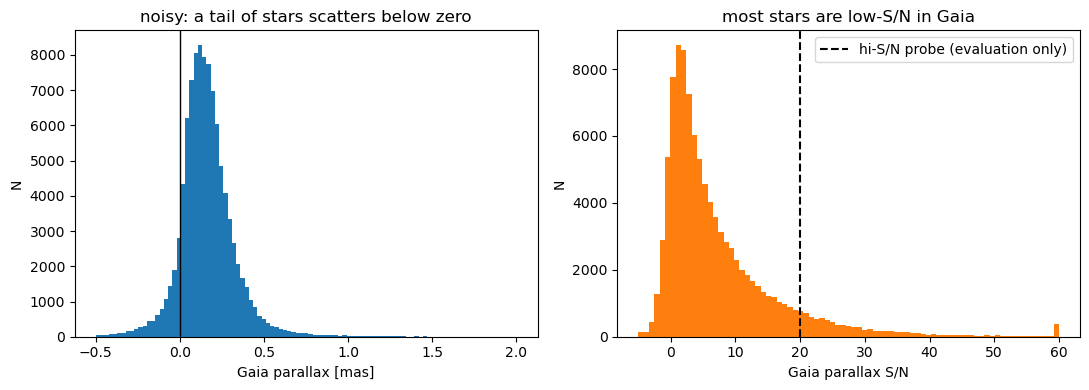

In [31]:
snr_a = merged["plx"] / merged["e_plx"]
snr_a = np.where(np.isfinite(snr_a), snr_a, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(merged["plx"], bins=np.linspace(-0.5, 2.0, 100), color="C0")
ax[0].axvline(0, color="k", lw=1)
ax[0].set(xlabel="Gaia parallax [mas]", ylabel="N",
          title="noisy: a tail of stars scatters below zero")

ax[1].hist(np.clip(snr_a[np.isfinite(snr_a)], -5, 60), bins=np.linspace(-5, 60, 80), color="C1")
ax[1].axvline(20, color="k", ls="--", label="hi-S/N probe (evaluation only)")
ax[1].set(xlabel="Gaia parallax S/N", ylabel="N",
          title="most stars are low-S/N in Gaia")
ax[1].legend()
plt.tight_layout()

## Step 2 — Assemble the features

Each star $n$ gets a feature vector (Paper I Eq. 11):

$$x_n = \big[\,1,\ \underbrace{G, BP, RP, J, H, K_s, W1, W2}_{\text{8 magnitudes}},\ \underbrace{\ln f_1, \dots, \ln f_L}_{\text{APOGEE spectrum, } L=7405 \text{ good pixels}}\,\big]$$

`assemble_features.py` builds this in three resumable stages (it runs on **Gadi** —
it needs disk for ~44k spectra and outbound HTTP):

1. **`crossmatch`** — one ADQL join through Gaia's precomputed neighbour tables
   (`tmass_best_neighbour`, `allwise_best_neighbour`) keyed on the catalog's 2MASS IDs
   → parallaxes + the 8 magnitudes.
2. **`fetch`** — download the DR14 `aspcapStar` FITS for every star from the SDSS SAS
   (the slow part; checkpointed, skips files already on disk).
3. **`build`** — read the pseudo-continuum-normalized flux (HDU1), build the *shared*
   good-pixel mask (drop pixels that are bad in any star), take $\ln(\text{flux})$,
   and write `features.npz` + `targets.npz`.

Stars with incomplete photometry are dropped — Paper I requires all 8 bands.

In [38]:
#!/usr/bin/env python3
"""
build_from_parquet.py — assemble the continuum-normalized spectral matrix for the
Hogg+18 spectrophotometric-parallax model from APOGEE parquet files.

Inputs (per star, on the 8575-pixel apStar grid), as array-valued parquet columns:
  raw        : the un-normalized spectrum S
  continuum  : the pseudo-continuum C
  ivar       : inverse variance of `raw` (APOGEE uses ivar==0 as its masked/no-data
               sentinel, so it stands in for APOGEE_PIXMASK until you add the bitmask)

Recipe:
  f  = S / C                normalized flux (~1 in continuum); feature is ln(f)
  iv = ivar * C**2          ivar propagated through the division
  bad per pixel/star, shared good-pixel mask = pixels good in >=(1-bad_frac_max)
  of stars (Hogg+18 keep ~7405 of 8575). Locally-bad survivors imputed to f=1
  (ln 0) with iv=0 so an inverse-variance-weighted fit ignores them.

Returns ln(flux) on the good-pixel subset plus the matching ivar (keep it — the
weighted fit / sigma_int head needs it).
"""
from __future__ import annotations
import numpy as np


def _stack(df, col):
    """Vstack an array-valued parquet column into (N, Lfull)."""
    return np.vstack([np.asarray(v, float) for v in df[col].to_numpy()])


def build_sample_from_parquet(
    parquet,
    spectrum_col: str = "flux",
    continuum_col: str = "continuum",
    ivar_col: str = "ivar",
    id_col: str | None = None,
    f_max: float = 2.0,
    bad_frac_max: float = 0.01,
):
    """Build (X_spec, IV_spec, good_pixel_mask, ids) from one or more parquet files.

    Parameters
    ----------
    parquet : str | Path | list
        A parquet path, a glob-expanded list of paths, or a pandas DataFrame.
        Multiple files are concatenated row-wise (one row == one star).
    spectrum_col, continuum_col, ivar_col : str
        Array-valued columns. `ivar` must be the inverse variance of `spectrum_col`
        (same array) — if your `ivar` was computed for an already-normalized flux,
        pass that flux as spectrum_col and a continuum of ones.
    id_col : str | None
        Optional per-star identifier column carried through to `ids`.
    f_max : float
        Upper sanity clip on normalized flux; >f_max flags a normalization failure.
    bad_frac_max : float
        A pixel is kept in the shared mask if it is bad in < bad_frac_max of stars.

    Returns
    -------
    dict with:
        X_spec          (N, L)   ln(normalized flux) on good pixels
        IV_spec         (N, L)   matching ivar (0 where imputed)
        good_pixel_mask (Lfull,) bool, True == kept
        ids             (N,)     ids if id_col given else integer index
    """
    import pandas as pd

    if isinstance(parquet, pd.DataFrame):
        df = parquet
    elif isinstance(parquet, (list, tuple)):
        df = pd.concat([pd.read_parquet(p) for p in parquet], ignore_index=True)
    else:
        df = pd.read_parquet(parquet)

    S  = _stack(df, spectrum_col)        # (N, Lfull) un-normalized spectrum
    C  = _stack(df, continuum_col)
    iv = _stack(df, ivar_col)
    N, Lfull = S.shape

    # --- normalize + propagate ivar ---
    C_safe = np.where(C > 0, C, np.nan)
    f  = S / C_safe
    iv = iv * C ** 2

    # --- per-pixel, per-star bad mask (ivar==0 is APOGEE's masked sentinel) ---
    bad = (
        ~np.isfinite(f) | ~np.isfinite(iv) | (iv <= 0)
        | (C <= 0) | (f <= 0) | (f > f_max)
    )

    # --- shared good-pixel mask: good in >=(1-bad_frac_max) of stars ---
    good = bad.mean(axis=0) < bad_frac_max
    L = int(good.sum())
    print(f"[parquet] stars={N}  full grid={Lfull}  good pixels kept={L} "
          f"(Hogg+18 kept 7405)")

    # --- impute locally-bad survivors: f=1 (ln 0), iv=0 (zero weight) ---
    f  = np.where(bad, 1.0, f)
    iv = np.where(bad, 0.0, iv)

    X_spec  = np.log(f[:, good])
    IV_spec = iv[:, good]

    ids = (df[id_col].to_numpy() if id_col is not None
           else np.arange(N))

    return {
        "X_spec": X_spec,
        "IV_spec": IV_spec,
        "good_pixel_mask": good,
        "ids": ids,
    }


In [39]:
corrected_spectra = build_sample_from_parquet(merged[merged["train"]], id_col="sdss_id")

[parquet] stars=27349  full grid=8575  good pixels kept=7492 (Hogg+18 kept 7405)


## Step 3 — The model: a linear fit in *log-parallax*, scored in *parallax space*

The model is deliberately simple (Paper I Eq. 11):

$$\ln \varpi^{(\mathrm{sp})}_n = \theta \cdot x_n$$

and $\theta$ is found by maximizing a Gaussian likelihood **in parallax space**:

$$\ln \mathcal{L}(\theta) = -\frac{1}{2}\sum_n \frac{\big(\varpi^{(a)}_n - e^{\theta\cdot x_n}\big)^2}{\sigma_n^2} + \text{const}$$

Two design decisions carry all the weight:

- **The exponential** guarantees the *predicted* parallax is positive — as a true
  parallax must be — while staying linear in the features (magnitudes, log-fluxes)
  inside the exponent.
- **The residual is taken in parallax space**, against the raw Gaia measurement.
  A star whose noisy Gaia parallax is negative still contributes a perfectly valid
  likelihood term. **No parallax cuts, ever** — cutting would bias $\theta$ toward
  nearby stars.

The real fit uses all 7,414 features and the spectra living on Gadi. Below is the
*same math* on a toy problem small enough to run here — synthetic "stars" with 6
features, heteroscedastic noise, and (as in real life) some observed parallaxes
scattering negative.

In [46]:
corrected_spectra['X_spec']

array([[-0.14995862, -0.16957842, -0.16244353, ..., -0.02024129,
        -0.07521409,  0.03865654],
       [-0.168144  , -0.17770669, -0.17070808, ..., -0.0164643 ,
        -0.0271213 , -0.03856649],
       [-0.14829606, -0.18525167, -0.18568705, ..., -0.04753404,
        -0.0731922 , -0.00162745],
       ...,
       [-0.13921719, -0.13901588, -0.14003969, ..., -0.20832379,
        -0.22692918, -0.29435936],
       [ 0.        ,  0.        ,  0.        , ..., -0.13270295,
        -0.14902516, -0.22799651],
       [-0.10505687, -0.10260158, -0.10307118, ..., -0.14614835,
        -0.14777125, -0.16559578]], shape=(27349, 7492))

In [47]:
merged[merged["train"]]['plx']

2         0.122790
10        0.190961
12        0.032424
13        0.221700
14        0.204332
            ...   
100238    0.019423
100246    0.424125
100247    0.096199
100252    0.025378
100253    0.122018
Name: plx, Length: 27349, dtype: float32

In [71]:
# === Step 3 (real data): fit  ln(plx_sp) = theta . x  in PARALLAX space ===
# Identical objective to the toy, now on 8 magnitudes + ~7492 ln-flux pixels.

# --- features/targets, all sliced to the SAME merged["train"] rows ---
tr       = merged["train"].values
ids_tr   = merged.loc[tr, "sdss_id"].values
phot_tr  = merged.loc[tr, label_cols].to_numpy(float)      # (N, 8) mags
spec_tr  = corrected_spectra["X_spec"]                      # (N, L) ln-flux, row-aligned to tr
plx_tr   = merged.loc[tr, "plx"].to_numpy(float)           # mas; NEGATIVES KEPT
err_tr   = merged.loc[tr, "e_plx"].to_numpy(float)
fold_tr  = merged.loc[tr, "sample"].to_numpy()             # 'A' / 'B'
assert spec_tr.shape[0] == phot_tr.shape[0] == len(plx_tr), "row counts differ"

# usable rows: finite features + finite, positive-error target (sign of plx is free)
good = (np.isfinite(plx_tr) & np.isfinite(err_tr) & (err_tr > 0)
        & np.isfinite(phot_tr).all(1) & np.isfinite(spec_tr).all(1))
ids_tr, phot_tr, spec_tr, plx_tr, err_tr, fold_tr = (
    a[good] for a in (ids_tr, phot_tr, spec_tr, plx_tr, err_tr, fold_tr))
print(f"usable training stars : {good.sum()}")
print(f"negative parallaxes   : {100*(plx_tr < 0).mean():.1f}%  (kept in the fit)")

# --- standardize with GIVEN stats (so a held-out fold uses TRAIN stats), prepend 1 ---
def design(phot, spec, stats=None):
    A = np.hstack([phot, spec]).astype(float)
    if stats is None:
        mu, sd = A.mean(0), A.std(0)
        sd[sd < 1e-8] = 1.0                       # near-constant (imputed) pixels -> ~0
        stats = (mu, sd)
    mu, sd = stats
    A = (A - mu) / sd
    return np.hstack([np.ones((len(A), 1)), A]), stats

# --- the fit: log-space ridge warm-start, then parallax-space refine (jitted) ---
import jax
jax.config.update("jax_enable_x64", True)          # parallax residuals want float64
import jax.numpy as jnp
from scipy.optimize import minimize

LAM = 1.   # ridge strength — the one knob; minimize the Step-7 held-out scatter over it

def fit_parallax_model(X, plx, sigma, lam=LAM, maxiter=2000):
    """theta for plx ~ exp(X @ theta): Gaussian-in-parallax NLL + L2 ridge.

    Robustness (this is why the naive theta=0 start stalled): we warm-start with a
    ridge least-squares fit of ln(plx) on the positive-parallax stars — a near-linear
    solution — and AVERAGE the data term over stars. Without the 1/N scaling the
    1/sigma^2 weights make the first L-BFGS step overshoot into the exp() clip
    plateau, where the gradient is flat, and the optimizer quits at theta=0.
    """
    X = np.asarray(X, float); plx = np.asarray(plx, float); sigma = np.asarray(sigma, float)
    N, D = X.shape
    reg = np.full(D, lam); reg[0] = 0.0            # never penalize the intercept

    # warm start in log space (ln needs plx>0)
    pos = plx > 0
    Xw, yw = X[pos], np.log(plx[pos])
    try:
        theta0 = np.linalg.solve(Xw.T @ Xw + np.diag(reg) * pos.sum(), Xw.T @ yw)
    except np.linalg.LinAlgError:
        theta0 = np.zeros(D); theta0[0] = np.log(np.median(plx[pos]))

    # refine the true parallax-space objective
    Xj, yj, sj, regj = (jnp.asarray(np.asarray(a, float)) for a in (X, plx, sigma, reg))
    invN = 1.0 / N

    @jax.jit
    def value_and_grad(theta):
        def obj(th):
            m = jnp.exp(jnp.clip(Xj @ th, -30, 30))      # predicted parallax > 0, overflow-guarded
            r = (yj - m) / sj                            # residual in PARALLAX space
            return 0.5 * invN * jnp.sum(r ** 2) + 0.5 * jnp.sum(regj * th ** 2)
        return jax.value_and_grad(obj)(theta)

    def scipy_obj(theta):
        f, g = value_and_grad(jnp.asarray(theta))
        return float(f), np.asarray(g, np.float64)

    res = minimize(scipy_obj, theta0, jac=True, method="L-BFGS-B",
                   options={"maxiter": maxiter, "maxfun": 4 * maxiter})
    return res.x, res

# --- sanity fit on ALL training stars (in-sample; the honest A/B fit is Step 4) ---
X_all, stats_all = design(phot_tr, spec_tr)
theta, res = fit_parallax_model(X_all, plx_tr, err_tr)
plx_sp_insample = np.exp(np.clip(X_all @ theta, -30, 30))
print(f"converged: {res.success} | iters: {res.nit} | final obj: {res.fun:.5f}")
print(f"spec parallax median: {np.median(plx_sp_insample):.3f} mas "
      f"(Gaia median {np.median(plx_tr):.3f} mas)")
print(f"theta head (intercept + 8 phot): {np.round(theta[:9], 3)}")


usable training stars : 27349
negative parallaxes   : 7.7%  (kept in the fit)
converged: True | iters: 1 | final obj: 5.40476
spec parallax median: 0.162 mas (Gaia median 0.187 mas)
theta head (intercept + 8 phot): [-1.795 -0.036 -0.022 -0.039 -0.063 -0.07  -0.071 -0.07  -0.07 ]


### Step 3 result — the fit converged (and why it nearly didn't)

The toy started L-BFGS from `theta=0`. On the real data that start predicts ~1 mas for
every star while the true parallaxes are ~0.1 mas, and the `1/sigma^2` weights
(sigma ~ 0.02 mas) make the gradient ~10⁷ — so the first step overshot into the
`exp()` overflow guard, the line search stalled, and `theta` stayed at zero (the
`iterations: 1`, all-zero result you saw).

The fix in `fit_parallax_model`: (1) **warm-start** from a ridge least-squares fit of
`ln(plx)` on the positive-parallax stars (a near-linear solution), and (2) **average
the data term over stars** so the gradient is `O(1)`. Below, an *in-sample* check —
does the converged model track Gaia on the hi-S/N probe? The honest out-of-sample
number comes in Step 4.

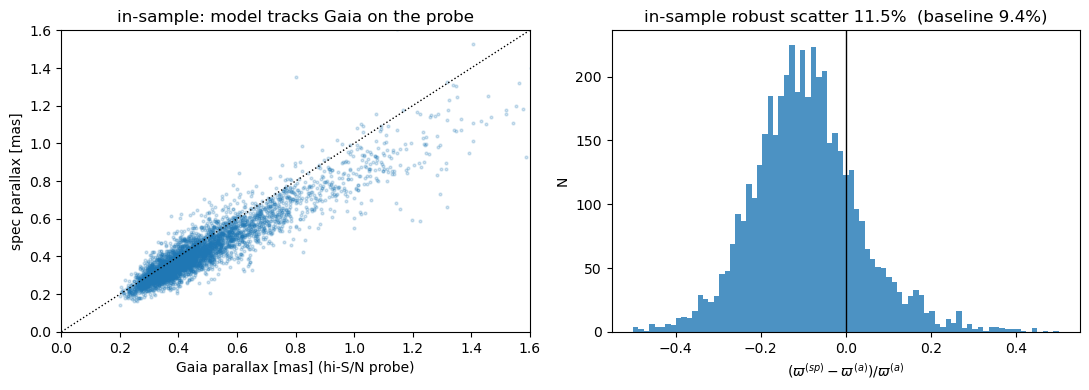

In [72]:
# In-sample recovery on the high-S/N probe (where Gaia is trustworthy).
# STILL IN-SAMPLE — the honest out-of-sample number is Step 4.
probe = E.hi_snr_mask(plx_tr, err_tr) & (plx_tr > 0)
frac_in = (plx_sp_insample[probe] - plx_tr[probe]) / plx_tr[probe]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(plx_tr[probe], plx_sp_insample[probe], s=4, alpha=0.2, color="C0")
ax[0].plot([0, 2], [0, 2], "k:", lw=1)
ax[0].set(xlim=(0, 1.6), ylim=(0, 1.6),
          xlabel="Gaia parallax [mas] (hi-S/N probe)", ylabel="spec parallax [mas]",
          title="in-sample: model tracks Gaia on the probe")

ax[1].hist(frac_in, bins=np.linspace(-0.5, 0.5, 80), color="C0", alpha=0.8)
ax[1].axvline(0, color="k", lw=1)
ax[1].set(xlabel=r"$(\varpi^{(sp)}-\varpi^{(a)})/\varpi^{(a)}$", ylabel="N",
          title=f"in-sample robust scatter {100*E.robust_scatter(frac_in):.1f}%  (baseline 9.4%)")
plt.tight_layout()

## Step 4 — A/B cross-validation: never let a star score itself

The published catalog shipped with cross-validated `spec_parallax`. Here we *produce*
those predictions: split the training set into halves **A** and **B** (the `sample`
column), fit one model on each half, and predict **every star with the model trained
on the OTHER half**. So all spec parallaxes below are out-of-sample.

This is the rule any new model must preserve: train on A → predict B; train on B →
predict A. We also carry the training fold's standardization onto the held-out fold —
re-standardizing on the test fold would leak.

In [73]:
# Train TWO models — one per fold — and predict each fold with the OTHER model, so
# every spec parallax is out-of-sample. The held-out fold is standardized with the
# TRAIN fold's stats (re-standardizing on the test fold would leak).
plx_sp_cv = np.empty_like(plx_tr)
for hold in ("A", "B"):
    fit_on = fold_tr != hold                                    # train on the complement
    Xf, stats = design(phot_tr[fit_on], spec_tr[fit_on])
    th, r = fit_parallax_model(Xf, plx_tr[fit_on], err_tr[fit_on])
    Xh, _ = design(phot_tr[~fit_on], spec_tr[~fit_on], stats)   # apply TRAIN stats
    plx_sp_cv[~fit_on] = np.exp(np.clip(Xh @ th, -30, 30))
    print(f"train !{hold} -> predict {hold}: {(~fit_on).sum():>6} stars  (converged {r.success})")

# spec-parallax uncertainty: constant FRACTIONAL error = out-of-sample scatter on the
# hi-S/N probe (paper's '~7% everywhere'). A full model would emit per-star sigma_int.
probe = E.hi_snr_mask(plx_tr, err_tr) & (plx_tr > 0)
frac_sigma = E.robust_scatter(np.log(plx_sp_cv[probe]) - np.log(plx_tr[probe]))
err_sp_cv  = frac_sigma * plx_sp_cv
print(f"adopted fractional spec error: {100*frac_sigma:.1f}%")

# package as a spphot_eval 'cat' dict so the baseline harness scores us unchanged
cat_real = {
    "plx_a":  plx_tr,    "err_a":  err_tr,
    "plx_sp": plx_sp_cv, "err_sp": err_sp_cv,
    "train":  np.ones(len(plx_tr), bool),
    "sample": fold_tr,
    "id":     ids_tr,
}

train !A -> predict A:  13674 stars  (converged True)
train !B -> predict B:  13675 stars  (converged True)
adopted fractional spec error: 13.7%


## Step 5 — The predictions and their uncertainties

The cross-validated outputs are `cat_real["plx_sp"]` and a `spec_parallax_err`. Our
simple linear model doesn't emit a per-star error, so we assign a **constant
fractional** uncertainty equal to the out-of-sample scatter on the hi-S/N probe
(Step 4) — the analogue of the paper's "~7% everywhere". That makes the spec histogram
below a single spike; a heteroscedastic model would spread it into a genuine per-star
distribution (exactly the upgrade Step 9 targets).

median fractional error — spec: 13.7%   Gaia: 15%


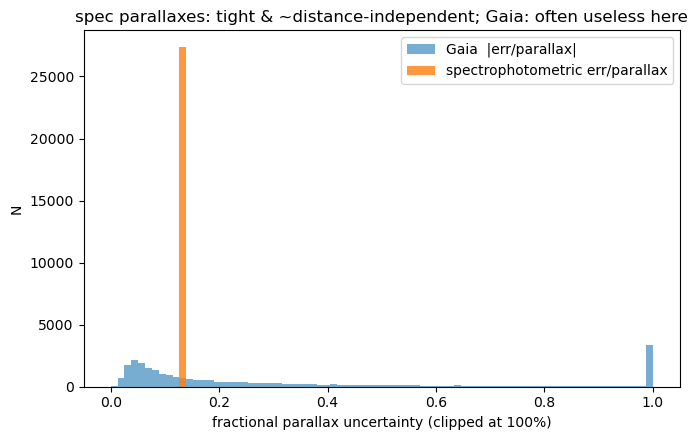

In [74]:
frac_sp = cat_real["err_sp"] / cat_real["plx_sp"]            # spec: always positive
with np.errstate(divide="ignore", invalid="ignore"):
    frac_a = np.abs(cat_real["err_a"] / cat_real["plx_a"])   # Gaia: |err/plx|
frac_a = frac_a[np.isfinite(frac_a)]

print(f"median fractional error — spec: {100*np.median(frac_sp):.1f}%   "
      f"Gaia: {100*np.median(frac_a):.0f}%")

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, 1.0, 80)
ax.hist(np.clip(frac_a, 0, 1),  bins=bins, alpha=0.6, label="Gaia  |err/parallax|")
ax.hist(np.clip(frac_sp, 0, 1), bins=bins, alpha=0.8, label="spectrophotometric err/parallax")
ax.set(xlabel="fractional parallax uncertainty (clipped at 100%)", ylabel="N",
       title="spec parallaxes: tight & ~distance-independent; Gaia: often useless here")
ax.legend()
plt.tight_layout()

## Step 6 — Parallax → distance

With a parallax guaranteed positive ($e^{\theta\cdot x}$) and a few-percent precise,
the naive inversion is finally safe:

$$d\,[\mathrm{kpc}] = \frac{1}{\varpi^{(\mathrm{sp})}\,[\mathrm{mas}]}$$

For raw Gaia parallaxes this is treacherous — undefined for the negative ones, biased
once the fractional error exceeds ~20%. So the **distance** comes from the spec
parallax, while all **scoring** (Step 7) stays in parallax space and never inverts.

median spec distance: 6.15 kpc;  farthest: 86.1 kpc


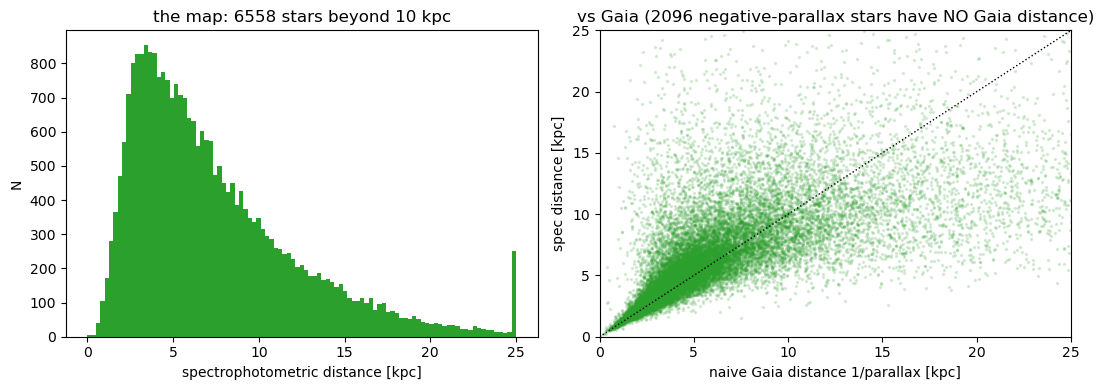

In [68]:
d_sp = 1.0 / cat_real["plx_sp"]                          # kpc (plx in mas), always defined

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(np.clip(d_sp, 0, 25), bins=np.linspace(0, 25, 100), color="C2")
ax[0].set(xlabel="spectrophotometric distance [kpc]", ylabel="N",
          title=f"the map: {(d_sp > 10).sum()} stars beyond 10 kpc")

ok = cat_real["plx_a"] > 0                               # naive Gaia inversion exists at all
ax[1].scatter(1.0 / cat_real["plx_a"][ok], d_sp[ok], s=2, alpha=0.15, color="C2")
ax[1].plot([0, 25], [0, 25], "k:", lw=1)
ax[1].set(xlim=(0, 25), ylim=(0, 25), xlabel="naive Gaia distance 1/parallax [kpc]",
          ylabel="spec distance [kpc]",
          title=f"vs Gaia ({(~ok).sum()} negative-parallax stars have NO Gaia distance)")
plt.tight_layout()
print(f"median spec distance: {np.median(d_sp):.2f} kpc;  farthest: {d_sp.max():.1f} kpc")

## Step 7 — Evaluation: the metrics to beat

Same harness as the baseline. The **hi-S/N probe** (Gaia S/N $\geq$ 20) acts as ground
truth — evaluation only, never a training input. `spphot_eval.evaluate` reports, on
each fold, the robust fractional scatter (headline; baseline **9.4%**), the bias
(median fractional residual), and the $\chi^2$ (honest errors $\Rightarrow$ mean $\approx 1$).

Read the per-fold scatter as the signal for tuning `LAM`: refit with a few values and
keep the one that minimizes it. Scatter far above 9.4% means under-fit or `LAM` too
large; an in-sample number (Step 3) much tighter than these out-of-sample ones means
overfit and `LAM` too small.

In [69]:
E.print_report(E.evaluate(cat_real, label="this notebook (linear, real data)"))
print()
for f in ("A", "B"):
    E.print_report(E.evaluate(cat_real, fold=f, label="this notebook"))
    print()

=== this notebook (linear, real data)  (fold: all) ===
  N total / hi-S/N probe : 27349 / 4656
  bias  (median frac resid)  : -7.60 %
  SCATTER (robust frac, <9% = beats Paper I) : 13.22 %
  median quoted spec err frac: 14.17 %
  chi2  mean / median / robust : 2.22 / 0.85 / 1.83
    (mean chi2 >> 1 means outlier-driven; honest errors -> ~1)

=== this notebook  (fold: A) ===
  N total / hi-S/N probe : 13674 / 2341
  bias  (median frac resid)  : -8.08 %
  SCATTER (robust frac, <9% = beats Paper I) : 13.14 %
  median quoted spec err frac: 14.17 %
  chi2  mean / median / robust : 2.23 / 0.85 / 1.82
    (mean chi2 >> 1 means outlier-driven; honest errors -> ~1)

=== this notebook  (fold: B) ===
  N total / hi-S/N probe : 13675 / 2315
  bias  (median frac resid)  : -6.92 %
  SCATTER (robust frac, <9% = beats Paper I) : 13.12 %
  median quoted spec err frac: 14.17 %
  chi2  mean / median / robust : 2.21 / 0.85 / 1.82
    (mean chi2 >> 1 means outlier-driven; honest errors -> ~1)



## Step 8 — Diagnostic figures

The same `spphot_plots` functions that render the baseline, now on our `cat_real`:
Fig. 2 (spec vs Gaia, training set + hi-S/N probe colored by Gaia S/N — should hug the
1:1 line on the probe) and the fractional-residual histogram whose width is the robust
scatter.

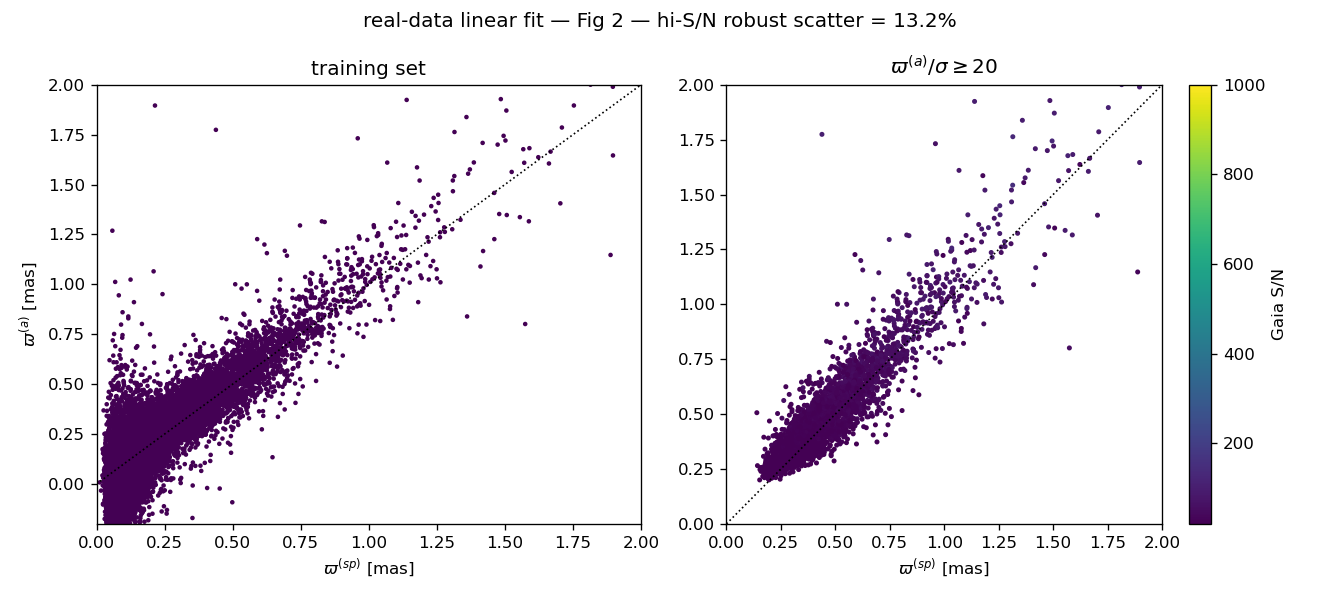

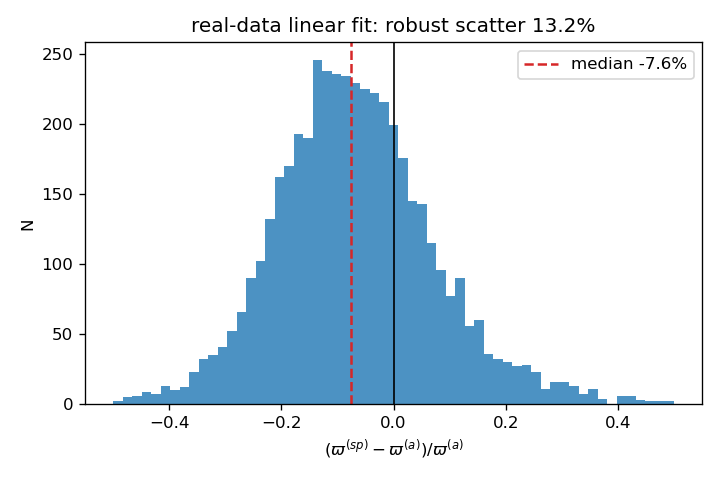

In [70]:
from IPython.display import Image, display

display(Image(P.fig2(cat_real, "nb_real_fig2.png",
                     title="real-data linear fit — Fig 2")))
display(Image(P.residual_hist(cat_real, "nb_real_resid_hist.png",
                              title="real-data linear fit")))

## Step 9 — From this linear baseline to your model

This notebook reproduced the Hogg+18 pipeline end-to-end on the **real** APOGEE+Gaia
data: features straight from the parquet, a parallax-space linear fit, A/B
cross-validation, and scoring on identical footing to the published catalog. The
linear model *is* the baseline to beat.

To swap in a heteroscedastic NN, change only the fit (Step 4): keep the parallax-space
Gaussian likelihood and the `exp()` link, but let the network output both `plx_sp` and
a per-star `sigma_int`, and keep the A/B fold discipline. Then score it exactly as in
Step 7:

```python
E.print_report(E.evaluate(cat_nn, fold="B", label="NN"))
P.compare_scatter(cat_real, cat_nn, "compare.png")   # does it tighten the core?
```

**Beating the baseline means all three:** robust scatter **< 9.4%**; mean $\chi^2$
closer to 1 (the $\sigma_{\rm int}$ head absorbing the dusty/crowded outliers that
inflate it here); and A/B fold independence preserved — never leak.